In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./../data/diamonds.csv")
df

,Id,Shape,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Messurements,Price
0,1638147,CUSHION,0.55,SI2,E,EX,EX,VG,N,5.05-4.35×2.94,"1,378.65"
1,1630155,CUSHION,0.50,VVS1,FANCY,EX,EX,VG,F,4.60-4.31×2.92,"1,379.74"
2,1612606,CUSHION,0.51,VS2,H,EX,EX,VG,N,4.71-4.35×2.94,"1,380.19"
3,1638140,CUSHION,0.50,VS2,H,EX,EX,VG,N,4.91-4.26×2.88,"1,380.61"
4,1536093,CUSHION,0.53,SI1,D,EX,VG,VG,N,4.70-4.46×3.01,"1,383.13"
...,...,...,...,...,...,...,...,...,...,...,...
6334,1751206,ROUND,0.50,SI1,E,EX,EX,EX,N,5.00-5.04×3.18,"2,453.10"
6335,1773024,ROUND,0.50,SI1,E,EX,EX,EX,N,5.03-5.06×3.16,"2,453.10"
6336,1789435,ROUND,0.50,VS2,D,VG,EX,VG,N,4.93-4.96×3.19,"2,453.20"
6337,1774887,ROUND,0.52,SI1,H,EX,EX,EX,N,5.11-5.13×3.20,"2,453.41"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6339 entries, 0 to 6338
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            6339 non-null   object 
 1   Shape         6339 non-null   object 
 2   Weight        6339 non-null   float64
 3   Clarity       6319 non-null   object 
 4   Colour        6339 non-null   object 
 5   Cut           6337 non-null   object 
 6   Polish        6338 non-null   object 
 7   Symmetry      6332 non-null   object 
 8   Fluorescence  6337 non-null   object 
 9   Messurements  6339 non-null   object 
 10  Price         6339 non-null   object 
dtypes: float64(1), object(10)
memory usage: 544.9+ KB


In [4]:
missing_values = df.isnull().sum()
missing_values

Id               0
Shape            0
Weight           0
Clarity         20
Colour           0
Cut              2
Polish           1
Symmetry         7
Fluorescence     2
Messurements     0
Price            0
dtype: int64

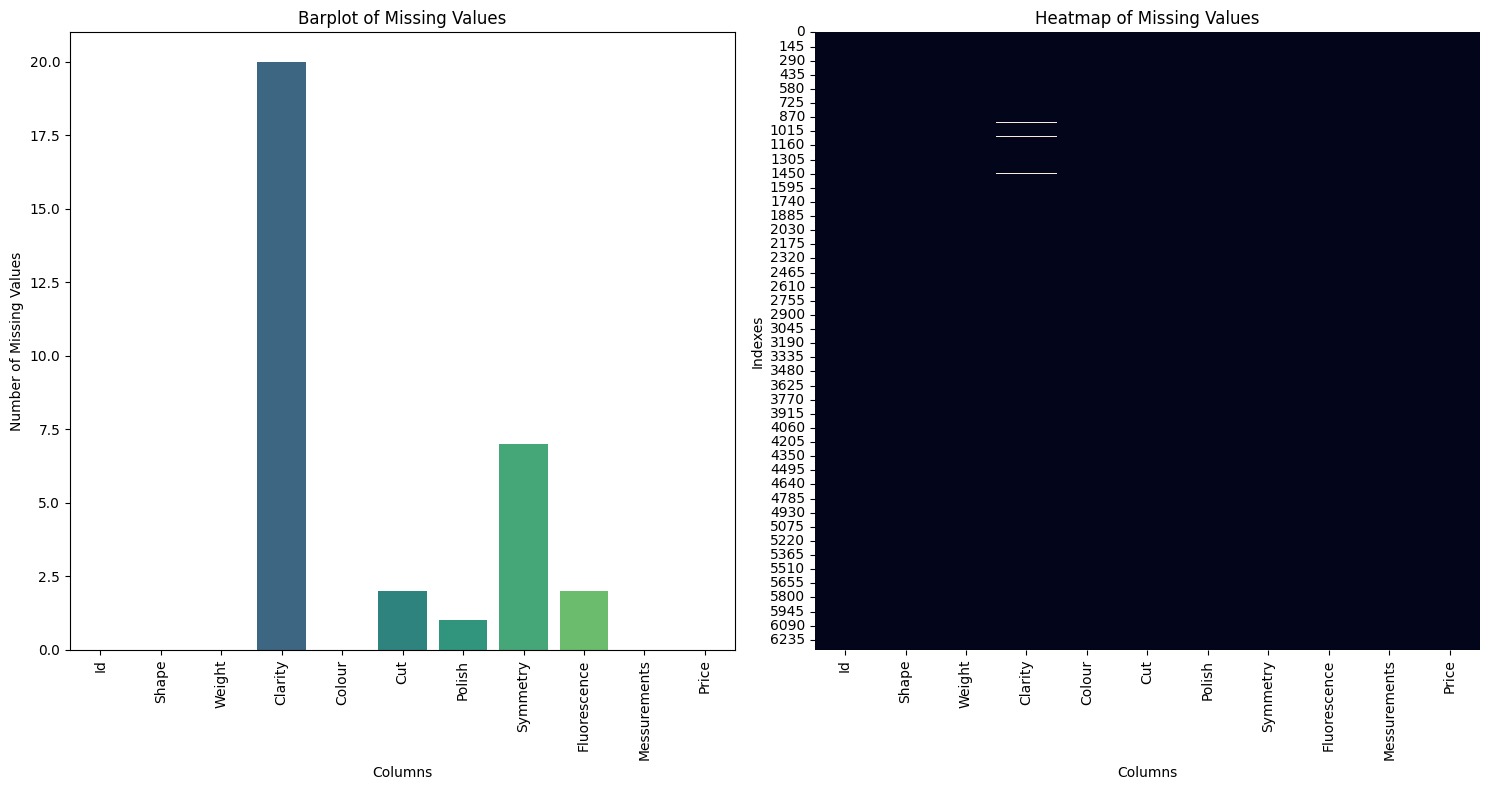

In [5]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15,8))

sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis', ax=ax1)
ax1.set_title('Barplot of Missing Values')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
ax1.set_xlabel('Columns')
ax1.set_ylabel('Number of Missing Values')

sns.heatmap(df.isnull(), cbar=False, ax=ax2)
ax2.set_title('Heatmap of Missing Values')
ax2.set_xlabel("Columns")
ax2.set_ylabel("Indexes")

plt.tight_layout()
plt.show()

In [6]:
df['Clarity'].fillna(df['Clarity'].mode()[0], inplace=True)
df['Cut'].fillna(df['Cut'].mode()[0], inplace=True)
df['Polish'].fillna(df['Polish'].mode()[0], inplace=True)
df['Symmetry'].fillna(df['Symmetry'].mode()[0], inplace=True)
df['Fluorescence'].fillna(df['Fluorescence'].mode()[0], inplace=True)

In [7]:
df.isnull().sum()

Id              0
Shape           0
Weight          0
Clarity         0
Colour          0
Cut             0
Polish          0
Symmetry        0
Fluorescence    0
Messurements    0
Price           0
dtype: int64

In [8]:
num_duplicates = df.duplicated().sum()
num_duplicates

348

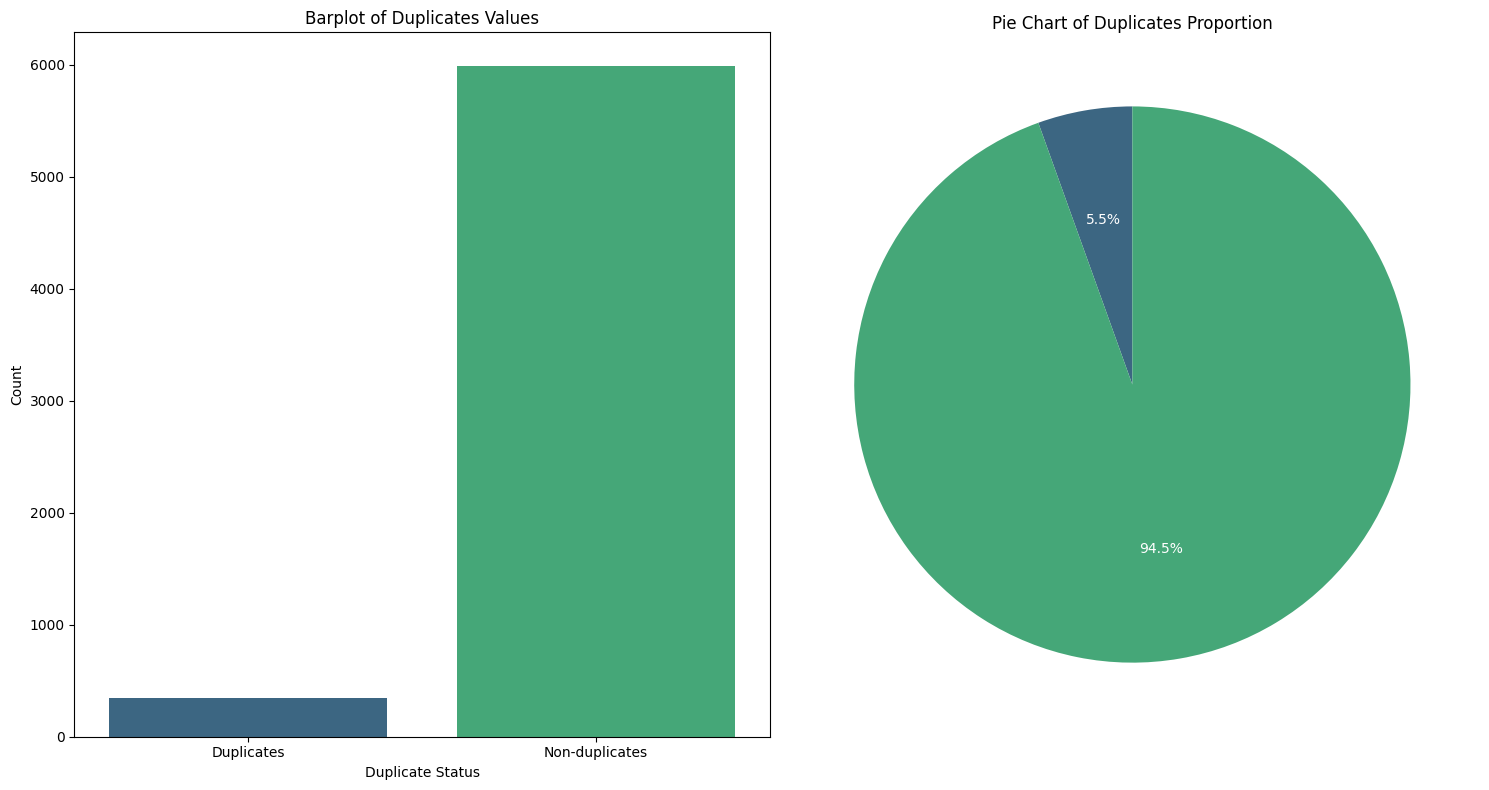

In [9]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15,8))

sns.barplot(x=['Duplicates', 'Non-duplicates'], y=[num_duplicates, len(df) - num_duplicates], palette='viridis', ax=ax1)
ax1.set_title('Barplot of Duplicates Values')
ax1.set_xlabel('Duplicate Status')
ax1.set_ylabel('Count')

labels = ['Duplicates', 'Non-duplicates']
sizes = [num_duplicates, len(df) - num_duplicates]
ax2.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#3c6682', '#45a778'], textprops={'color':'white'})
ax2.set_title('Pie Chart of Duplicates Proportion')

plt.tight_layout()
plt.show()

In [10]:
df = df.drop_duplicates()
df.duplicated().sum()

0

In [11]:
df

,Id,Shape,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Messurements,Price
0,1638147,CUSHION,0.55,SI2,E,EX,EX,VG,N,5.05-4.35×2.94,"1,378.65"
1,1630155,CUSHION,0.50,VVS1,FANCY,EX,EX,VG,F,4.60-4.31×2.92,"1,379.74"
2,1612606,CUSHION,0.51,VS2,H,EX,EX,VG,N,4.71-4.35×2.94,"1,380.19"
3,1638140,CUSHION,0.50,VS2,H,EX,EX,VG,N,4.91-4.26×2.88,"1,380.61"
4,1536093,CUSHION,0.53,SI1,D,EX,VG,VG,N,4.70-4.46×3.01,"1,383.13"
...,...,...,...,...,...,...,...,...,...,...,...
6332,1751206,ROUND,0.50,SI1,E,EX,EX,EX,N,5.00-5.04×3.18,"2,453.10"
6333,1773024,ROUND,0.50,SI1,E,EX,EX,EX,N,5.03-5.06×3.16,"2,453.10"
6336,1789435,ROUND,0.50,VS2,D,VG,EX,VG,N,4.93-4.96×3.19,"2,453.20"
6337,1774887,ROUND,0.52,SI1,H,EX,EX,EX,N,5.11-5.13×3.20,"2,453.41"


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5991 entries, 0 to 6338
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            5991 non-null   object 
 1   Shape         5991 non-null   object 
 2   Weight        5991 non-null   float64
 3   Clarity       5991 non-null   object 
 4   Colour        5991 non-null   object 
 5   Cut           5991 non-null   object 
 6   Polish        5991 non-null   object 
 7   Symmetry      5991 non-null   object 
 8   Fluorescence  5991 non-null   object 
 9   Messurements  5991 non-null   object 
 10  Price         5991 non-null   object 
dtypes: float64(1), object(10)
memory usage: 561.7+ KB


In [13]:
df.Price

0       1,378.65
1       1,379.74
2       1,380.19
3       1,380.61
4       1,383.13
          ...   
6332    2,453.10
6333    2,453.10
6336    2,453.20
6337    2,453.41
6338    2,453.69
Name: Price, Length: 5991, dtype: object

In [ ]:
df['Price'] = df['Price'].str.replace(',', '').astype(float)

In [15]:
df.Messurements

0       5.05-4.35×2.94
1       4.60-4.31×2.92
2       4.71-4.35×2.94
3       4.91-4.26×2.88
4       4.70-4.46×3.01
             ...      
6332    5.00-5.04×3.18
6333    5.03-5.06×3.16
6336    4.93-4.96×3.19
6337    5.11-5.13×3.20
6338    5.09-5.13×3.12
Name: Messurements, Length: 5991, dtype: object

In [ ]:
def getNumbers(str):
    import re
    
    array = re.findall(r'[0-9]', str)
    return array

df['Messurements'] = df['Messurements'].apply(lambda x: getNumbers(x) )
df['Messurements'] = df['Messurements'].apply(lambda x: ''.join(x) )

df['Length']= df['Messurements'].str[:3].astype(float) /100
df['Width'] = df['Messurements'].str[3:6].astype(float) /100
df['Depth'] = df['Messurements'].str[6:].astype(float) / 100

df.drop(['Messurements'], axis = 1, inplace = True) 

In [17]:
df

,Id,Shape,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Price,Length,Width,Depth
0,1638147,CUSHION,0.55,SI2,E,EX,EX,VG,N,1378.65,5.05,4.35,2.94
1,1630155,CUSHION,0.50,VVS1,FANCY,EX,EX,VG,F,1379.74,4.60,4.31,2.92
2,1612606,CUSHION,0.51,VS2,H,EX,EX,VG,N,1380.19,4.71,4.35,2.94
3,1638140,CUSHION,0.50,VS2,H,EX,EX,VG,N,1380.61,4.91,4.26,2.88
4,1536093,CUSHION,0.53,SI1,D,EX,VG,VG,N,1383.13,4.70,4.46,3.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6332,1751206,ROUND,0.50,SI1,E,EX,EX,EX,N,2453.10,5.00,5.04,3.18
6333,1773024,ROUND,0.50,SI1,E,EX,EX,EX,N,2453.10,5.03,5.06,3.16
6336,1789435,ROUND,0.50,VS2,D,VG,EX,VG,N,2453.20,4.93,4.96,3.19
6337,1774887,ROUND,0.52,SI1,H,EX,EX,EX,N,2453.41,5.11,5.13,3.20


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5991 entries, 0 to 6338
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            5991 non-null   object 
 1   Shape         5991 non-null   object 
 2   Weight        5991 non-null   float64
 3   Clarity       5991 non-null   object 
 4   Colour        5991 non-null   object 
 5   Cut           5991 non-null   object 
 6   Polish        5991 non-null   object 
 7   Symmetry      5991 non-null   object 
 8   Fluorescence  5991 non-null   object 
 9   Price         5991 non-null   float64
 10  Length        5991 non-null   float64
 11  Width         5991 non-null   float64
 12  Depth         5991 non-null   float64
dtypes: float64(5), object(8)
memory usage: 655.3+ KB


In [19]:
def optimize_dataframe(df):
    optimized_df = df.copy()

    # Iterate through each column
    for col in optimized_df.columns:
        col_data = optimized_df[col]
        dtype = col_data.dtype

        # Convert object columns to category dtype if less than 50% unique
        if dtype == object:
            num_unique = len(col_data.unique())
            num_total = len(col_data)
            if num_unique / num_total < 0.5:
                optimized_df[col] = col_data.astype('category')

        elif dtype == 'int64':
            col_min = col_data.min()
            col_max = col_data.max()
            if col_min >= 0:
                if col_max < 256:
                    optimized_df[col] = col_data.astype('uint8')
                elif col_max < 65536:
                    optimized_df[col] = col_data.astype('uint16')
                elif col_max < 4294967296:
                    optimized_df[col] = col_data.astype('uint32')
                else:
                    optimized_df[col] = col_data.astype('uint64')
            elif col_min > np.iinfo(np.int8).min and col_max < np.iinfo(np.int8).max:
                optimized_df[col] = col_data.astype('int8')
            elif col_min > np.iinfo(np.int16).min and col_max < np.iinfo(np.int16).max:
                optimized_df[col] = col_data.astype('int16')
            elif col_min > np.iinfo(np.int32).min and col_max < np.iinfo(np.int32).max:
                optimized_df[col] = col_data.astype('int32')
            else:
                optimized_df[col] = col_data.astype('int64')

        elif dtype == 'float64':
            col_min = col_data.min()
            col_max = col_data.max()
            if col_min >= np.finfo(np.float16).min and col_max < np.finfo(np.float16).max:
                optimized_df[col] = col_data.astype('float16')
            elif col_min >= np.finfo(np.float32).min and col_max < np.finfo(np.float32).max:
                optimized_df[col] = col_data.astype('float32')
            else:
                optimized_df[col] = col_data.astype('float64')

    # Print memory usage before and after optimization
    before_mem = df.memory_usage().sum() / 1024**2
    after_mem = optimized_df.memory_usage().sum() / 1024**2
    print(f"Memory usage before optimization: {before_mem:.2f} MB")
    print(f"Memory usage after optimization: {after_mem:.2f} MB")

    return optimized_df

In [20]:
optimized_df = optimize_dataframe(df)

Memory usage before optimization: 0.64 MB
Memory usage after optimization: 0.20 MB


In [21]:
optimized_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5991 entries, 0 to 6338
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Id            5991 non-null   object  
 1   Shape         5991 non-null   category
 2   Weight        5991 non-null   float16 
 3   Clarity       5991 non-null   category
 4   Colour        5991 non-null   category
 5   Cut           5991 non-null   category
 6   Polish        5991 non-null   category
 7   Symmetry      5991 non-null   category
 8   Fluorescence  5991 non-null   category
 9   Price         5991 non-null   float32 
 10  Length        5991 non-null   float16 
 11  Width         5991 non-null   float16 
 12  Depth         5991 non-null   float16 
dtypes: category(7), float16(4), float32(1), object(1)
memory usage: 207.1+ KB


In [22]:
optimized_df.to_csv('./../data/clean_diamonds.csv', index=False)

In [23]:
optimized_df.to_parquet('./../data/clean_diamonds.br', compression='BROTLI')  